## DDPM Architectural Implementation from Scratch; PyTorch

#### High level overview of what i'll be building in this notebook

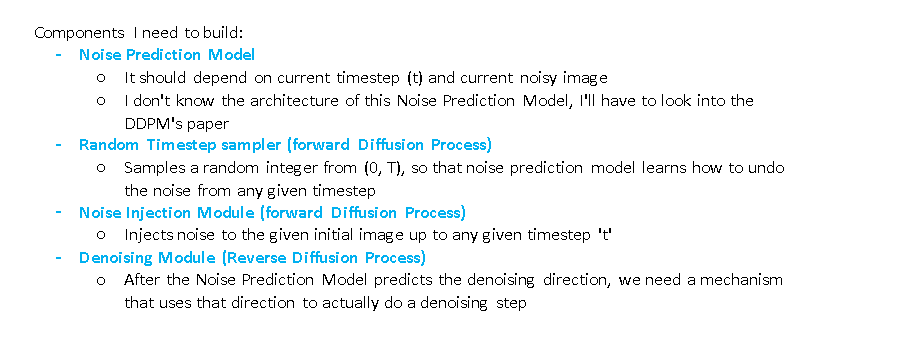

## How DDPM works; mathematical overview

### During Training

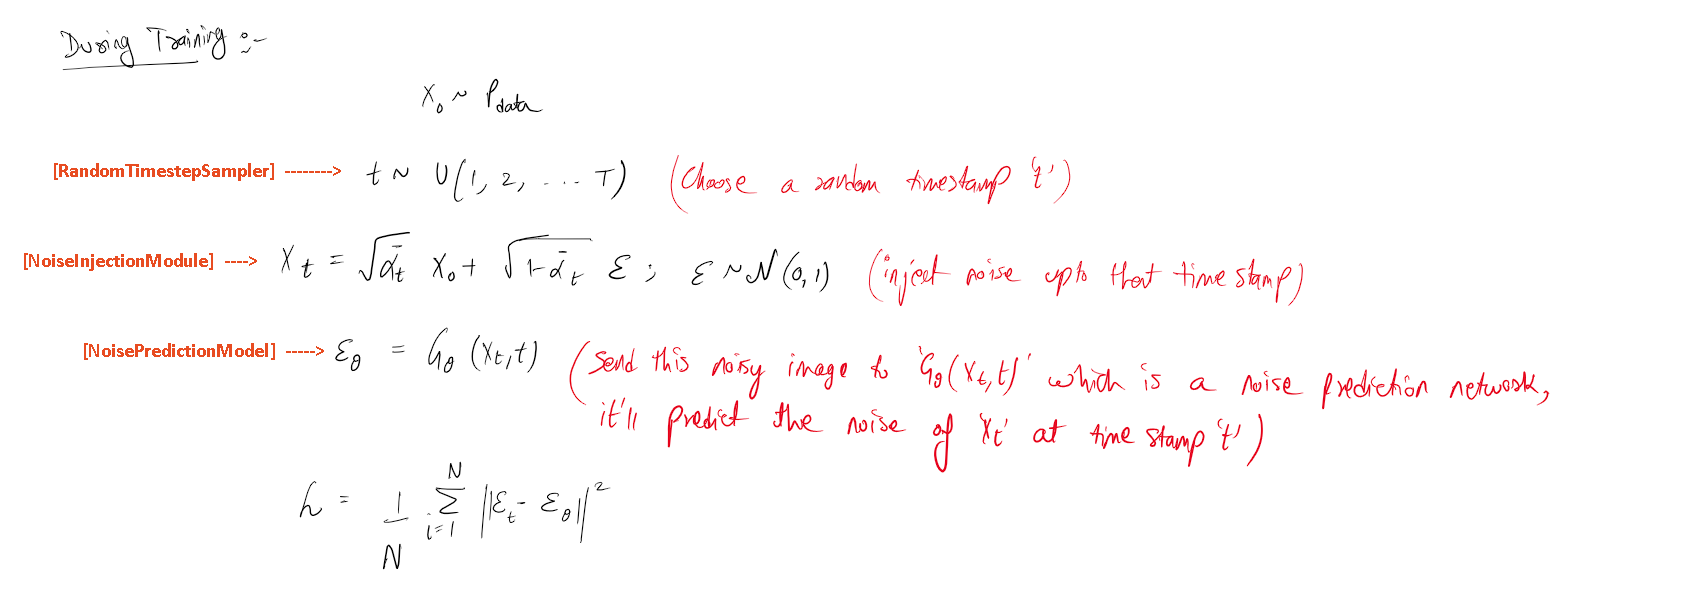

### During Inference

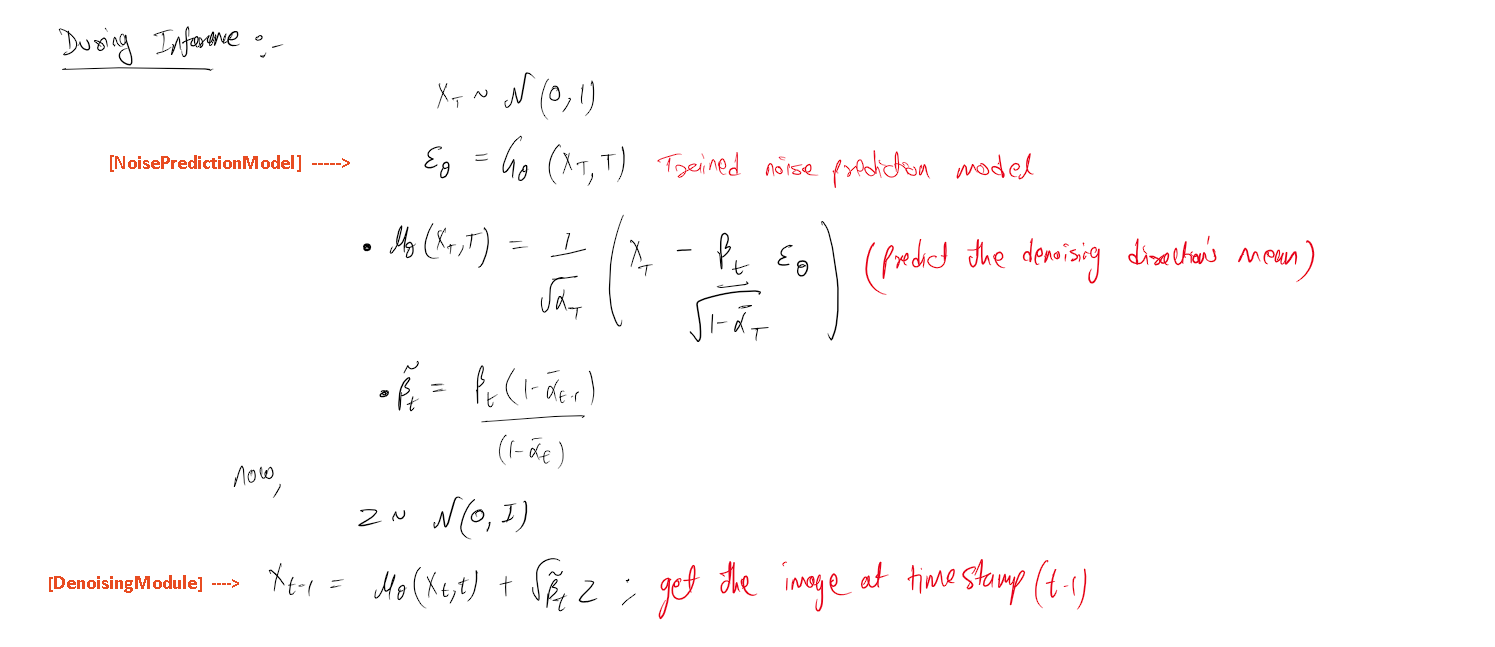

### How forward Diffusion Process works

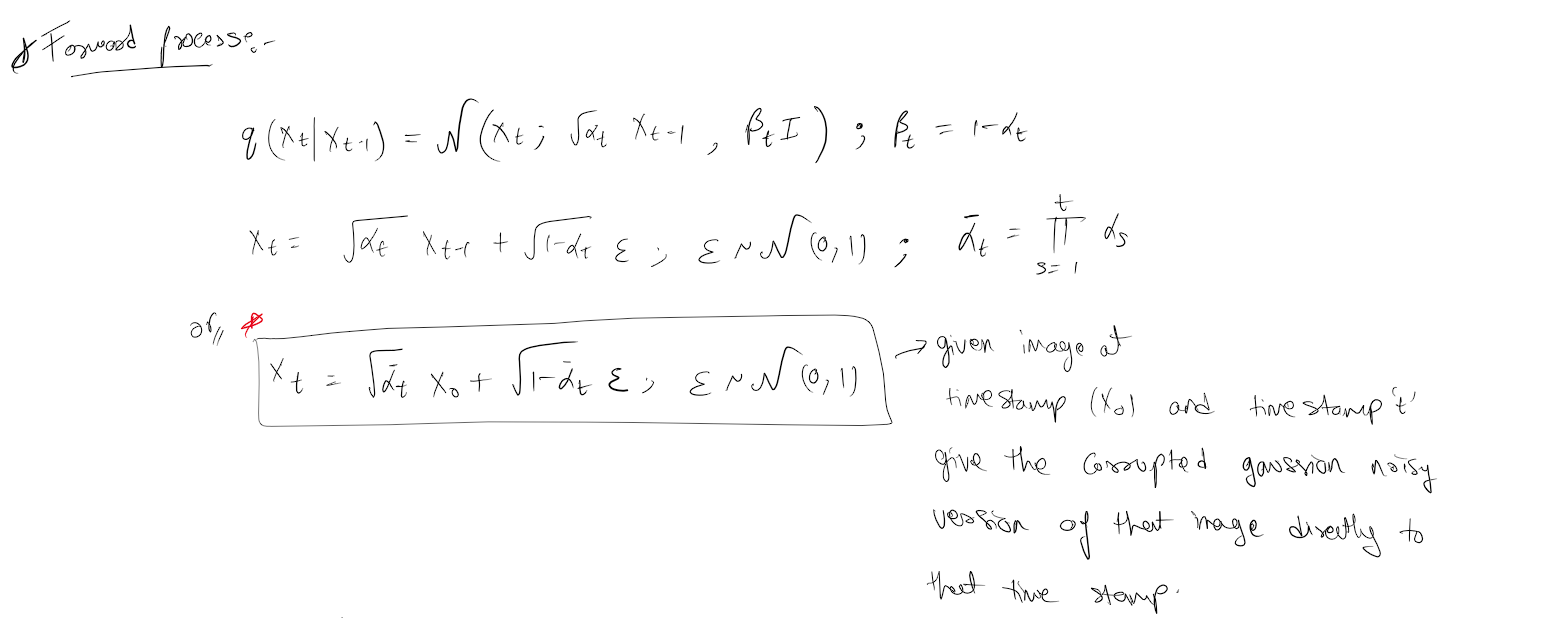

### How Reverse Diffusion Process works

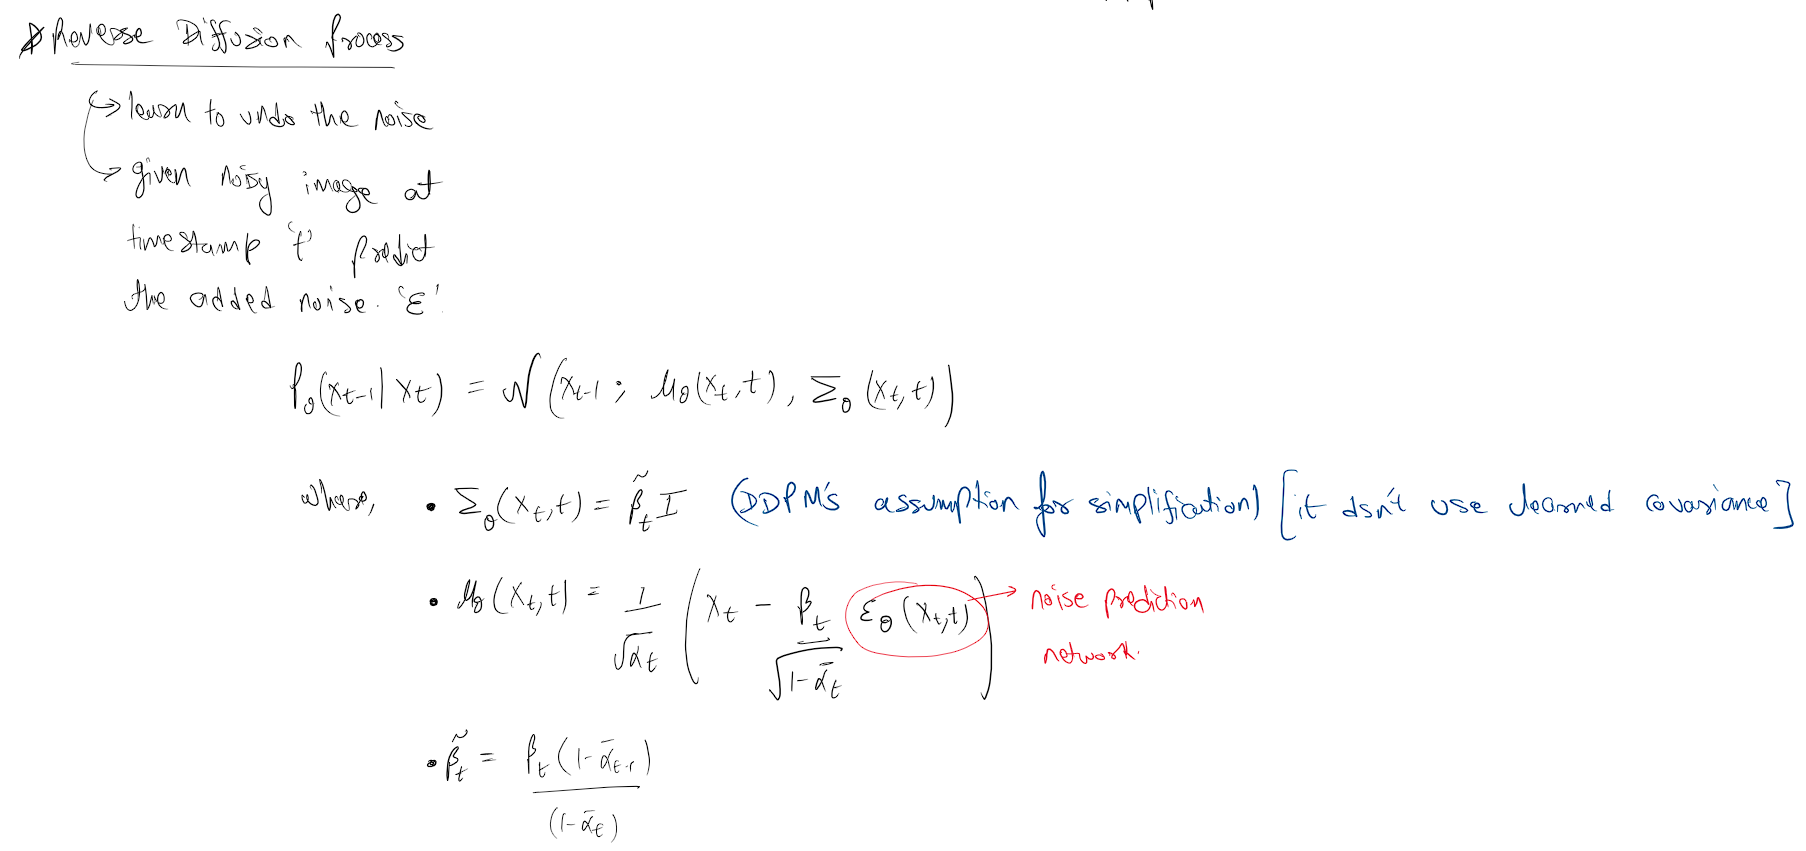

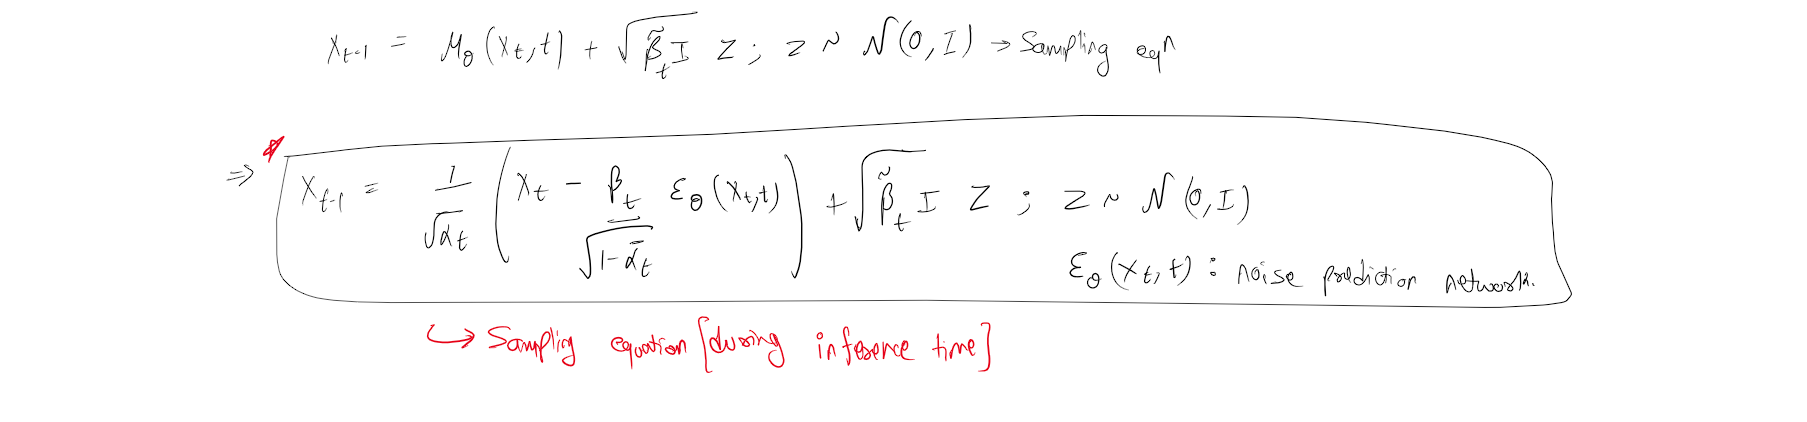

### Training Vannila DDPM

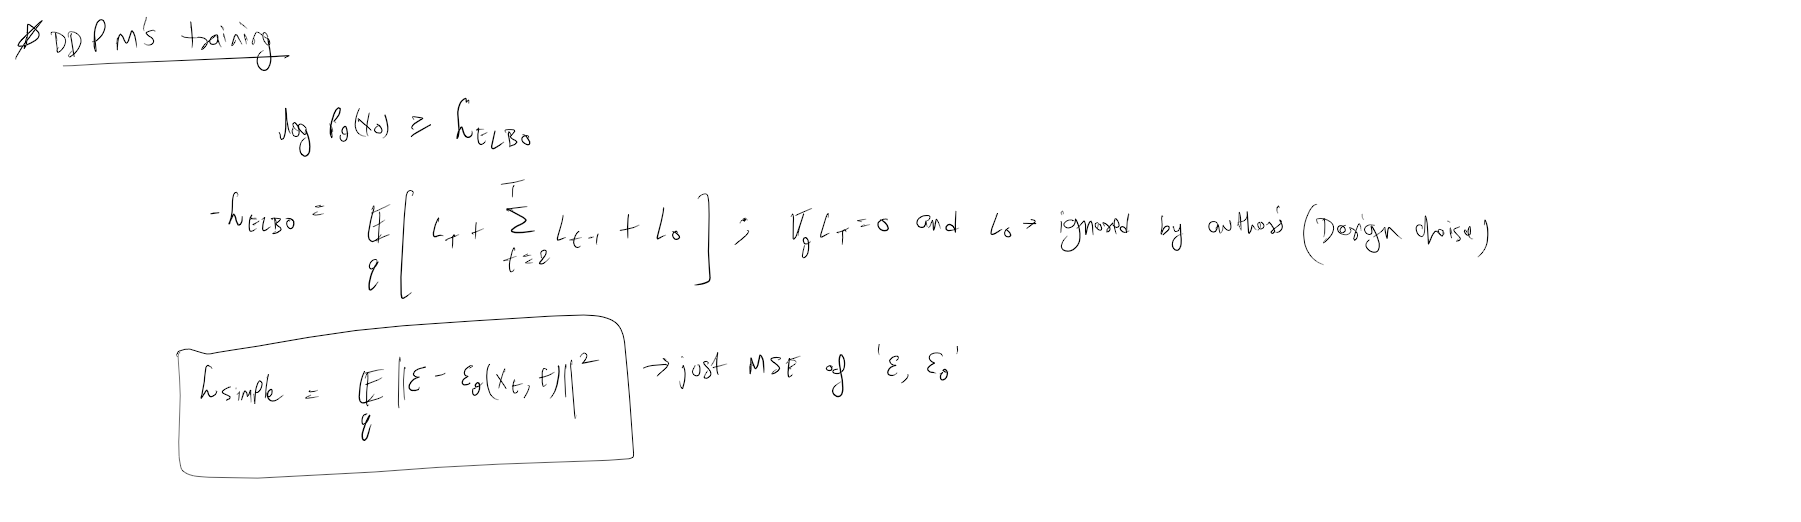

## Let's Build it

---

## Random Timestep Sampler

- we need this Random timestep sampler because we need to learn a Denoising model for any timestep 't'
- this also improves the underlying performance

In [1]:
DEBUG = True # i'm setting it to 'True' for Development purpose
config = {
    "T": 1000,
    "batch_size": 1,
    "beta_start": 1e-4,
    "beta_end": 2e-2,
    "test_img_dir": "../../test_images/bmw_m4.png",

    # self-attention based bottleneck layer
    "q_dim": 32,
    "v_dim": 32,
    "time_embed": 32,

    "T_test": 500
}

In [2]:
import torch
import torch.nn as nn

class RandomTimeStepSampler(nn.Module):
    """
    Gives a random TimeStep for the Noise Prediction Model to train on
    """
    def __init__(self, config):
        super().__init__()
        self.T = config["T"]
        self.batch_size = config["batch_size"]
    
    def forward(self):
        return torch.randint(low = 1, high = self.T + 1, size = (self.batch_size, ), dtype = torch.int32)

In [3]:
import torch
import torch.nn as nn

class DeterministicTimeStepSampler(nn.Module):
    """
    Gives a deterministic TimeStep for Experimentation Purpose
    """
    def __init__(self, config):
        super().__init__()
        self.T_test = config["T_test"]
        self.batch_size = config["batch_size"]
    
    def forward(self):
        return torch.ones(self.batch_size, dtype=torch.int32) * self.T_test

In [4]:
if DEBUG:
    print("-- Inside Random TimeStep Sampler -- ")
    deterministic_timestep_sampler = DeterministicTimeStepSampler(config = config)
    print(f"Random timestep: {deterministic_timestep_sampler()}")

-- Inside Random TimeStep Sampler -- 
Random timestep: tensor([500], dtype=torch.int32)


In [5]:
if DEBUG:
    print("-- Inside Random TimeStep Sampler -- ")
    random_timestep_sampler = RandomTimeStepSampler(config = config)
    print(f"Random timestep: {random_timestep_sampler()}")

-- Inside Random TimeStep Sampler -- 
Random timestep: tensor([983], dtype=torch.int32)


---

## Noise Injection Module

- Now that we have Timestep, it's time to inject the noise upto that timestep
- Mathematically, 
$$
t \sim U(\{1,2,\ldots,T\})
$$

$$
x_t = \sqrt{\bar{\alpha}_t}\,x_0
      + \sqrt{1-\bar{\alpha}_t}\,\epsilon,
\qquad
\epsilon \sim \mathcal{N}(0,I)
$$
- Given Fresh Image $ x_0 $ and timestep $ t $ sampled from 'RandomTimeStepSampler' inject the noise and give me the noisy image $ x_t $

---

## Linear Noise Scheduler

In [6]:
class LinearNoiseScheduler(nn.Module):
    """
    This Linear Noise Scheduler gives the noise, 'beta_t', injected during noise injection
    """
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.beta_start = config["beta_start"] # where, beta_end > beta_start means gradually increase the amount of noise added
        self.beta_end = config["beta_end"]
        self.T = config["T"]

        beta = torch.zeros(self.T + 1)
        beta[1:] = torch.linspace(self.beta_start, self.beta_end, self.T)

        alpha = 1 - beta

        self.register_buffer("beta", beta)
        self.register_buffer("alpha", alpha)

    def forward(self):
        return (self.alpha, self.beta)

In [7]:
if DEBUG:
    noise_scheduler = LinearNoiseScheduler(config = config)
    alpha, beta = noise_scheduler()
    print(alpha[:10], beta[:10], beta.shape)

tensor([1.0000, 0.9999, 0.9999, 0.9999, 0.9998, 0.9998, 0.9998, 0.9998, 0.9998,
        0.9997]) tensor([0.0000e+00, 1.0000e-04, 1.1992e-04, 1.3984e-04, 1.5976e-04, 1.7968e-04,
        1.9960e-04, 2.1952e-04, 2.3944e-04, 2.5936e-04]) torch.Size([1001])


## Noise Injector

In [8]:
import torch
import torch.nn as nn

class NoiseInjector(nn.Module):
    """
    Injects the noise upto the timestep 't' to the image x_0
    """
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.linear_noise_scheduler = LinearNoiseScheduler(config = config)
        self.alpha, self.beta = self.linear_noise_scheduler() # # alpha.shape = [T+1], beta.shape = [T+1], T: Total timestep
        alpha_bar = torch.cumprod(self.alpha, dim = 0) # alpha_bar.shape = [T+1]
        self.register_buffer("alpha_bar", alpha_bar)


    def forward(self, x_0: torch.Tensor, t: torch.Tensor):
        """
        x_0: Original Image at timestep '0'     shape = [B, C, H, W]
        t: Timestep up to which we want to inject the noise shape = [B, ]
        """
        B, C, H, W = x_0.shape
        eps = torch.randn_like(x_0) # get the gaussian noise
        self.alpha_bar_t = self.alpha_bar[t].view(B, 1, 1, 1) # (B, 1, 1, 1)
        noisy_image = torch.clip((torch.sqrt(self.alpha_bar_t) * x_0 + torch.sqrt((1 - self.alpha_bar_t)) * eps), min = 0, max = 1)
        return noisy_image, eps

## Noise Injection Pipeline

In [9]:
class NoiseInjectionPipeline(nn.Module):
    def __init__(self, config, random: bool = True):
        super().__init__()
        if random:
            self.time_step_sampler = RandomTimeStepSampler(config = config)
        else:
            self.time_step_sampler = DeterministicTimeStepSampler(config = config)
        self.noise_injector = NoiseInjector(config = config)

        # Get the Timesteps for all Images in the batch
        # t = self.random_timestep_sampler()
        t = self.time_step_sampler()
        self.register_buffer("t", t)

    def forward(self, x_0: torch.tensor):
        return self.noise_injector(x_0, self.t), self.t        

In [10]:
def load_test_img():
    from PIL import Image
    from torchvision import transforms

    image = Image.open(config["test_img_dir"]).convert("RGB")

    transform = transforms.Compose([
        transforms.ToTensor(),
    ])

    x_0 = transform(image)
    x_0 = x_0.unsqueeze(0)
    return x_0

In [11]:
if DEBUG:
    x_0 = load_test_img()
    # initial_img = torch.rand(1, 3, 64, 64)
    noise_injection_pipieline = NoiseInjectionPipeline(config)
    (noisy_img, _), t = noise_injection_pipieline(x_0)
    print(f"initial_img.shape = {x_0.shape}")
    print(f"noisy_img.shape = {noisy_img.shape}")

initial_img.shape = torch.Size([1, 3, 600, 800])
noisy_img.shape = torch.Size([1, 3, 600, 800])


In [12]:
def plot_img(img, title: str):
    img = img.squeeze(0).permute(1, 2, 0)
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

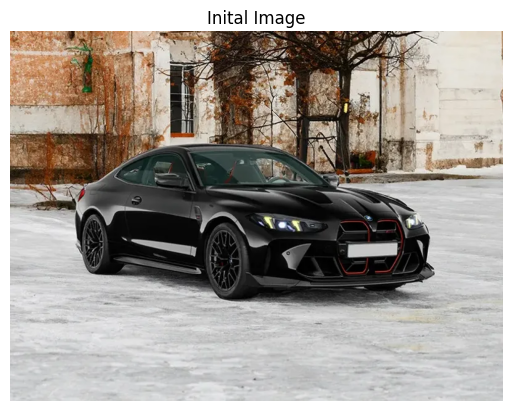

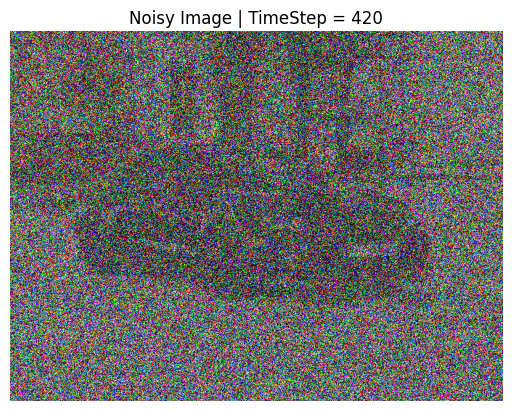

In [13]:
if DEBUG:
    plot_img(x_0, title = "Inital Image")
    plot_img(noisy_img, title = f"Noisy Image | TimeStep = {t.item()}")

## Noise Injection Pipeline accross various Timesteps

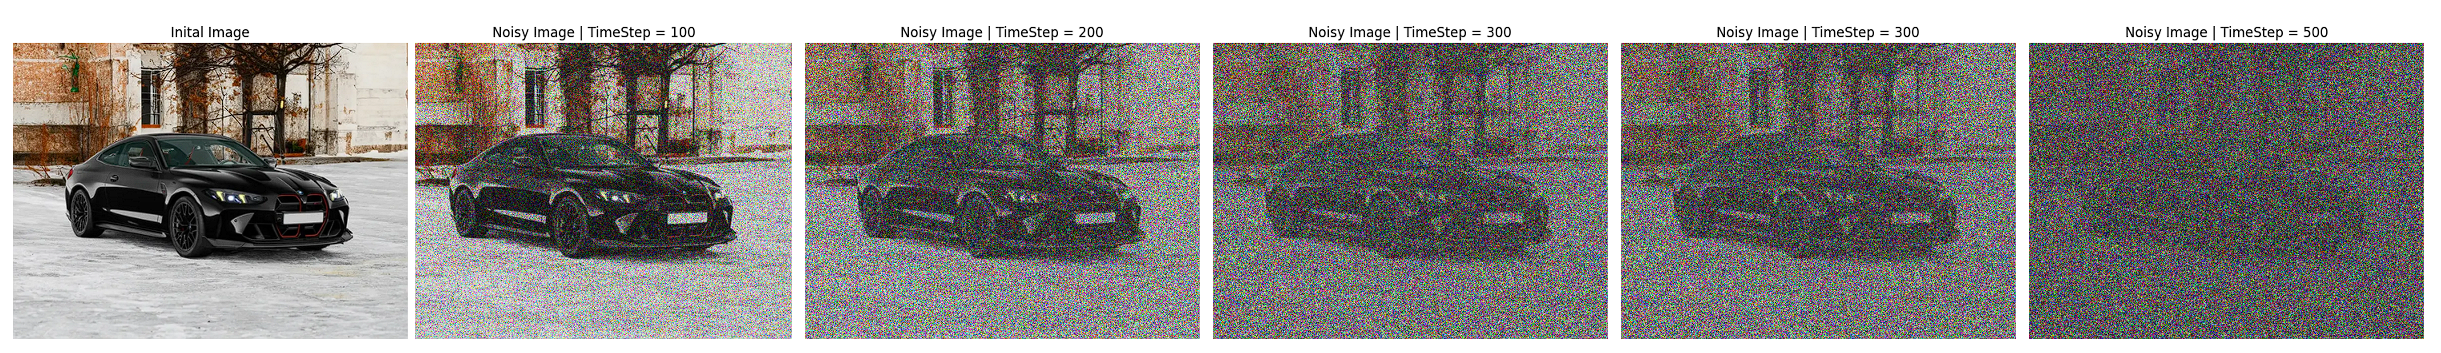

---

## Noise Prediction Network

In [14]:
from abc import ABC, abstractmethod
import torch
import torch.nn as nn
import torch.nn.functional as F


class NoiseModel(nn.Module, ABC):
    @abstractmethod
    def forward(self, x: torch.Tensor, t_e: torch.Tensor) -> torch.Tensor:
        raise NotImplementedError

class UNet(NoiseModel):
    def __init__(self, attention_bottleneck: bool = True, *, config):
        super().__init__()
        self.time_embed = config["time_embed"]
        self.attention_bottleneck = attention_bottleneck

        # Timestep Injection: Key idea is to inject the timestep accross each and every up and down step (after every convolution layer)
        self.time_down_1 = nn.Linear(self.time_embed, 64)
        self.time_down_2 = nn.Linear(self.time_embed, 128)
        self.time_down_3 = nn.Linear(self.time_embed, 256)
        self.time_down_4 = nn.Linear(self.time_embed, 512)
        self.time_down_5 = nn.Linear(self.time_embed, 512)

        self.time_up_0 = nn.Linear(self.time_embed, 512)
        self.time_up_1 = nn.Linear(self.time_embed, 256)
        self.time_up_2 = nn.Linear(self.time_embed, 128)
        self.time_up_3 = nn.Linear(self.time_embed, 64)

        # Encoder
        self.down_1 = nn.Conv2d(3, 64, 3, 1, 1)
        self.down_2 = nn.Conv2d(64, 128, 3, 2, 1)
        self.down_3 = nn.Conv2d(128, 256, 3, 1, 1)
        self.down_4 = nn.Conv2d(256, 512, 3, 2, 1)
        self.down_5 = nn.Conv2d(512, 512, 3, 2, 1) # for reducing 64 x 64 ---> 32 x 32

        # Decoder
        self.up_0 = nn.ConvTranspose2d(512, 512, 4, 2, 1) # counter part for self.down_5; 32 x 32 ---> 64 x 64
        self.up_1 = nn.ConvTranspose2d(1024, 256, 4, 2, 1)
        self.up_2 = nn.ConvTranspose2d(512, 128, 3, 1, 1)
        self.up_3 = nn.ConvTranspose2d(256, 64, 4, 2, 1)
        self.up_4 = nn.ConvTranspose2d(128, 3, 3, 1, 1)

        if self.attention_bottleneck:
            q_dim = config["q_dim"]
            v_dim = config["v_dim"]
            self.q_dim = q_dim
            self.v_dim = v_dim

            self.w_q = nn.Conv2d(512, q_dim, 1, 1, 0)
            self.w_k = nn.Conv2d(512, q_dim, 1, 1, 0)
            self.w_v = nn.Conv2d(512, v_dim, 1, 1, 0)

            self.out_projection = nn.Conv2d(self.v_dim, 512, 1, 1, 0)

    def _inject_timestep(self, x_t: torch.Tensor, t_e: torch.Tensor, projection_layer: nn.Linear):
        # x_t.shape = B, C, H, W
        # t_e.shape = B, D
        t_e = projection_layer(t_e).unsqueeze(-1).unsqueeze(-1) # B, C --> (B, C, 1, 1)
        return x_t + t_e


    def _apply_skip_connection(self, x1, x2):
        # x1.shape = [B, C1, H, W]
        # x2.shape = [B, C2, H, W]
        assert ((x1.shape[-1] == x2.shape[-1]) and (x1.shape[-2] == x2.shape[-2])), "Spatial dim of x1 and x2 be same"
        return torch.cat([x1, x2], dim = 1) # shape = [B, C1+C2, H, W]

    def _get_attention_scores(self, Q: torch.Tensor, K: torch.Tensor):
        return F.softmax((Q @ K.transpose(-1, -2)) / (self.q_dim ** 0.5), dim = -1) # [B, C, q_dim] @ [B, q_dim, C] = = [B, C, C]
    
    def _apply_attention_bottleneck(self, bottle_tensor: torch.Tensor):
        # bottle_tensor.shape = [B, 256, H, W]
        B, C, H, W = bottle_tensor.shape
        Q = self.w_q(bottle_tensor).flatten(2).transpose(1, 2) # shape = [B, q_dim, H, W] --> [B, q_dim, H * W] --> [B, H*W, q_dim]; C = H*W
        K = self.w_k(bottle_tensor).flatten(2).transpose(1, 2) # shape = [B, q_dim, H, W] --> [B, q_dim, H * W] --> [B, H*W, q_dim]; C = H*W
        V = self.w_v(bottle_tensor).flatten(2).transpose(1, 2) # shape = [B, v_dim, H, W] --> [B, v_dim, H * W] --> [B, H*W, v_dim]; C = H*W

        attn_scores = self._get_attention_scores(Q, K)
        self_attention = attn_scores @ V # [B, C, C] @ [B, C, v_dim] = [B, C, v_dim]
        self_attention = self_attention.transpose(-1, -2).reshape(B, self.v_dim, H, W)
        self_attention = self.out_projection(self_attention)
        return self_attention + bottle_tensor # [B, v_dim, H, W] --> [B, 512, H, W] # because decoder expects 512 dim

    def forward(self, x_t: torch.Tensor, t_e: torch.Tensor):
        """
        x_t: Noise Image, noise injected upto timestep 't'; shape = B, C, H, W
        t_e: TimeStep Embeddings: Shape = [B, D]
        """
        # Encoder Process
        s1 = self._inject_timestep(self.down_1(x_t), t_e, self.time_down_1)
        s2 = self._inject_timestep(self.down_2(s1), t_e, self.time_down_2)
        s3 = self._inject_timestep(self.down_3(s2), t_e, self.time_down_3)
        s4 = self._inject_timestep(self.down_4(s3), t_e, self.time_down_4)  # [B, 512, H, W]
        x_t = self._inject_timestep(self.down_5(s4), t_e, self.time_down_5) # [B, 512, H, W]

        # TODO: Add a bottelneck Self-attention layer, and i'll make it optional for experimentation purpose
        if self.attention_bottleneck:
            x_t = self._apply_attention_bottleneck(bottle_tensor = x_t)

        # Decoder Process
        x_t = self._inject_timestep(self.up_0(x_t), t_e, self.time_up_0) # [B, 256, H, W]
        x_t = self._inject_timestep(self.up_1(self._apply_skip_connection(x_t, s4)), t_e, self.time_up_1) # Shape = [B, 256+256, H, W] = [B, 512, H, W]
        x_t = self._inject_timestep(self.up_2(self._apply_skip_connection(x_t, s3)), t_e, self.time_up_2) # Shape = [B, 256+256, H, W] = [B, 512, H, W]
        x_t = self._inject_timestep(self.up_3(self._apply_skip_connection(x_t, s2)), t_e, self.time_up_3) # Shape = [B, 128+128, H, W] = [B, 256, H, W]
        x_t = self.up_4(self._apply_skip_connection(x_t, s1)) # Shape = [B, 64+64, H, W] = [B, 128, H, W]
        return x_t
    
class NoisePredictionPipeline(nn.Module):
    def __init__(self, config, noise_prediction_model: NoiseModel):
        super().__init__()
        self.T = config["T"]
        self.time_embed = config["time_embed"]
        self.time_step_embeddings = nn.Embedding(self.T, self.time_embed)
        self.noise_model = noise_prediction_model

    def forward(self, x_t: torch.Tensor, t: torch.Tensor):
        t_e = self.time_step_embeddings(t)
        return self.noise_model(x_t, t_e)

In [15]:
class DDPM(nn.Module):
    def __init__(self, noise_prediction_pipeline: NoisePredictionPipeline):
        super().__init__()
        self.noise_prediction_pipeline = noise_prediction_pipeline

    def forward(self, x_t: torch.Tensor, t: torch.Tensor):
        return self.noise_prediction_pipeline(x_t, t)

In [16]:
ddpm = DDPM(noise_prediction_pipeline = NoisePredictionPipeline(config = config, noise_prediction_model = UNet(attention_bottleneck = True, config = config)))
ddpm(torch.rand(1, 3, 256, 256), torch.zeros(1, dtype=torch.long)).shape

torch.Size([1, 3, 256, 256])